In [1]:
import sys
import torch
import transformers
import peft

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("PEFT:", peft.__version__)

print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU is not enabled in this Kaggle notebook."
    )

print("GPU:", torch.cuda.get_device_name(0))

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
Transformers: 5.0.0
PEFT: 0.19.1
CUDA available: True
GPU: Tesla T4


In [2]:
import random
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoImageProcessor,
    SiglipForImageClassification
)

from peft import LoraConfig

print("All imports successful.")

All imports successful.


In [3]:
SEED = 42

MODEL_NAME = "google/siglip-base-patch16-224"

CLASS_NAMES = [
    "Red sandstone",
    "Light sandstone",
    "Gray siltstone",
    "Mudstone",
    "Granite",
    "Basalt",
    "Marble"
]

LABEL2ID = {
    name: i
    for i, name in enumerate(CLASS_NAMES)
}

ID2LABEL = {
    i: name
    for i, name in enumerate(CLASS_NAMES)
}

NUM_CLASSES = len(CLASS_NAMES)

# -------------------------
# LoRA configuration
# -------------------------

LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

# -------------------------
# Training configuration
# -------------------------

BATCH_SIZE = 16
EPOCHS = 3

LEARNING_RATE = 2e-4
WEIGHT_DECAY = 0.01

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda")

print("Model:", MODEL_NAME)
print("Classes:", NUM_CLASSES)
print("LoRA rank:", LORA_R)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Device:", device)

Model: google/siglip-base-patch16-224
Classes: 7
LoRA rank: 16
Batch size: 16
Epochs: 3
Device: cuda


In [4]:
INPUT_ROOT = Path("/kaggle/input")

dataset_candidates = list(
    INPUT_ROOT.rglob("kaggle_dataset")
)

print("Dataset candidates:")

for path in dataset_candidates:
    print(path)

if not dataset_candidates:
    raise FileNotFoundError(
        "kaggle_dataset was not found. "
        "Attach the GeoSigLIP dataset using Add Input."
    )

DATA_ROOT = dataset_candidates[0]

print("\nUsing dataset:")
print(DATA_ROOT)

Dataset candidates:
/kaggle/input/datasets/utkarshrode/geosiglip-dcid-7-lithology-dataset/kaggle_dataset

Using dataset:
/kaggle/input/datasets/utkarshrode/geosiglip-dcid-7-lithology-dataset/kaggle_dataset


In [5]:
required_files = [
    "train.csv",
    "validation.csv",
    "test.csv"
]

for filename in required_files:

    path = DATA_ROOT / filename

    if not path.exists():
        raise FileNotFoundError(
            f"Missing file: {path}"
        )

IMAGE_ROOT = DATA_ROOT / "images"

if not IMAGE_ROOT.exists():
    raise FileNotFoundError(
        f"Missing images directory: {IMAGE_ROOT}"
    )

print("Dataset structure verified.")
print("\nContents:")

for item in DATA_ROOT.iterdir():

    print(
        "DIR :" if item.is_dir()
        else "FILE:",
        item.name
    )

Dataset structure verified.

Contents:
DIR : images
FILE: validation.csv
FILE: train.csv
FILE: test.csv


In [6]:
train_df = pd.read_csv(
    DATA_ROOT / "train.csv"
)

val_df = pd.read_csv(
    DATA_ROOT / "validation.csv"
)

test_df = pd.read_csv(
    DATA_ROOT / "test.csv"
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 2450
Validation: 1050
Test: 1750


In [7]:
train_df["image_path"] = train_df[
    "image_path"
].apply(
    lambda x: DATA_ROOT / str(x)
)

val_df["image_path"] = val_df[
    "image_path"
].apply(
    lambda x: DATA_ROOT / str(x)
)

test_df["image_path"] = test_df[
    "image_path"
].apply(
    lambda x: DATA_ROOT / str(x)
)

print(
    "Example path:",
    train_df["image_path"].iloc[0]
)

Example path: /kaggle/input/datasets/utkarshrode/geosiglip-dcid-7-lithology-dataset/kaggle_dataset/images/train/Granite/5.Granite_2029.jpg


In [8]:
for name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:

    exists = df["image_path"].apply(
        Path.exists
    )

    print(
        f"{name}: "
        f"{exists.sum()} / {len(df)}"
    )

    if not exists.all():

        print("\nMissing images:")
        print(
            df.loc[
                ~exists,
                "image_path"
            ].head(10)
        )

        raise FileNotFoundError(
            f"Missing images in {name}"
        )

Train: 2450 / 2450
Validation: 1050 / 1050
Test: 1750 / 1750


In [9]:
train_paths = set(
    train_df["image_path"]
)

val_paths = set(
    val_df["image_path"]
)

test_paths = set(
    test_df["image_path"]
)

train_val = len(
    train_paths & val_paths
)

train_test = len(
    train_paths & test_paths
)

val_test = len(
    val_paths & test_paths
)

print(
    "Train ∩ Validation:",
    train_val
)

print(
    "Train ∩ Test:",
    train_test
)

print(
    "Validation ∩ Test:",
    val_test
)

if train_val or train_test or val_test:
    raise ValueError(
        "Dataset leakage detected."
    )

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [10]:
from transformers import AutoImageProcessor

MODEL_NAME = "google/siglip-base-patch16-224"

processor = AutoImageProcessor.from_pretrained(
    MODEL_NAME
)

print("Processor loaded successfully.")
print("Model:", MODEL_NAME)

preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Processor loaded successfully.
Model: google/siglip-base-patch16-224


In [11]:
class LithologyDataset(Dataset):

    def __init__(
        self,
        dataframe,
        processor,
        label2id
    ):
        self.dataframe = dataframe.reset_index(
            drop=True
        )
        self.processor = processor
        self.label2id = label2id

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        encoded = self.processor(
            images=image,
            return_tensors="pt"
        )

        return {
            "pixel_values": encoded[
                "pixel_values"
            ].squeeze(0),

            "labels": torch.tensor(
                self.label2id[row["label"]],
                dtype=torch.long
            )
        }

In [12]:
train_dataset = LithologyDataset(
    train_df,
    processor,
    LABEL2ID
)

val_dataset = LithologyDataset(
    val_df,
    processor,
    LABEL2ID
)

print(
    "Training samples:",
    len(train_dataset)
)

print(
    "Validation samples:",
    len(val_dataset)
)

Training samples: 2450
Validation samples: 1050


In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print(
    "Training batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

Training batches: 154
Validation batches: 66


In [14]:
batch = next(iter(train_loader))

print(
    "Pixel values:",
    batch["pixel_values"].shape
)

print(
    "Labels:",
    batch["labels"].shape
)

Pixel values: torch.Size([16, 3, 224, 224])
Labels: torch.Size([16])


In [15]:
model = SiglipForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    label2id=LABEL2ID,
    id2label=ID2LABEL,
    ignore_mismatched_sizes=True
)

model = model.to(device)

print("SigLIP loaded.")
print(
    "Model device:",
    next(model.parameters()).device
)

config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SiglipForImageClassification LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     | 
-------------------------------------------------------------+------------+-
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED | 
text_model.final_layer_norm.weight                           | UNEXPECTED | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |

SigLIP loaded.
Model device: cuda:0


In [16]:
q_modules = []
v_modules = []

for name, module in model.named_modules():

    if name.endswith("q_proj"):
        q_modules.append(name)

    if name.endswith("v_proj"):
        v_modules.append(name)

print(
    "q_proj modules:",
    len(q_modules)
)

print(
    "v_proj modules:",
    len(v_modules)
)

print("\nExamples:")

for name in q_modules[:5]:
    print(name)

q_proj modules: 12
v_proj modules: 12

Examples:
vision_model.encoder.layers.0.self_attn.q_proj
vision_model.encoder.layers.1.self_attn.q_proj
vision_model.encoder.layers.2.self_attn.q_proj
vision_model.encoder.layers.3.self_attn.q_proj
vision_model.encoder.layers.4.self_attn.q_proj


In [17]:
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,

    target_modules=[
        "q_proj",
        "v_proj"
    ],

    modules_to_save=[
        "classifier"
    ],

    bias="none"
)

print(lora_config)

LoraConfig(task_type=None, peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.19.1', base_model_name_or_path=None, revision=None, inference_mode=False, r=16, target_modules={'v_proj', 'q_proj'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=['classifier'], init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, ensure_weight_tying=False)


In [18]:
# Cell 18 — Apply LoRA directly to SigLIP attention layers

class LoRALinear(torch.nn.Module):
    def __init__(self, base_layer, rank=16, alpha=32, dropout=0.05):
        super().__init__()

        self.base_layer = base_layer
        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank

        # Freeze pretrained layer
        for p in self.base_layer.parameters():
            p.requires_grad = False

        # Match the original layer's device and dtype
        device = base_layer.weight.device
        dtype = base_layer.weight.dtype

        self.lora_A = torch.nn.Linear(
            base_layer.in_features,
            rank,
            bias=False,
            device=device,
            dtype=dtype
        )

        self.lora_B = torch.nn.Linear(
            rank,
            base_layer.out_features,
            bias=False,
            device=device,
            dtype=dtype
        )

        self.dropout = torch.nn.Dropout(
            dropout
        )

        torch.nn.init.kaiming_uniform_(
            self.lora_A.weight,
            a=np.sqrt(5)
        )

        torch.nn.init.zeros_(
            self.lora_B.weight
        )

    def forward(self, x):
        return (
            self.base_layer(x)
            + self.scaling
            * self.lora_B(
                self.lora_A(
                    self.dropout(x)
                )
            )
        )


# Apply LoRA to every SigLIP vision attention q_proj and v_proj

replaced = 0

for layer in model.vision_model.encoder.layers:

    layer.self_attn.q_proj = LoRALinear(
        layer.self_attn.q_proj,
        rank=LORA_R,
        alpha=LORA_ALPHA,
        dropout=LORA_DROPOUT
    )

    layer.self_attn.v_proj = LoRALinear(
        layer.self_attn.v_proj,
        rank=LORA_R,
        alpha=LORA_ALPHA,
        dropout=LORA_DROPOUT
    )

    replaced += 2


# Freeze entire model first
for p in model.parameters():
    p.requires_grad = False


# Re-enable only LoRA parameters
for layer in model.vision_model.encoder.layers:

    for p in layer.self_attn.q_proj.lora_A.parameters():
        p.requires_grad = True

    for p in layer.self_attn.q_proj.lora_B.parameters():
        p.requires_grad = True

    for p in layer.self_attn.v_proj.lora_A.parameters():
        p.requires_grad = True

    for p in layer.self_attn.v_proj.lora_B.parameters():
        p.requires_grad = True


# Train the new 7-class classifier
for p in model.classifier.parameters():
    p.requires_grad = True


print("LoRA modules inserted:", replaced)
print("LoRA + classifier are trainable.")

LoRA modules inserted: 24
LoRA + classifier are trainable.


In [19]:
total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

trainable_percentage = (
    trainable_parameters
    / total_parameters
    * 100
)

print(
    "Total parameters:",
    f"{total_parameters:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

print(
    "Trainable percentage:",
    f"{trainable_percentage:.4f}%"
)

Total parameters: 93,479,431
Trainable parameters: 595,207
Trainable percentage: 0.6367%


In [20]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    [
        p
        for p in model.parameters()
        if p.requires_grad
    ],
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("Optimizer ready.")

Optimizer ready.


In [21]:
model.eval()

batch = next(iter(train_loader))

pixel_values = batch[
    "pixel_values"
].to(device)

labels = batch[
    "labels"
].to(device)

with torch.no_grad():

    outputs = model(
        pixel_values=pixel_values
    )

    logits = outputs.logits

    loss = criterion(
        logits,
        labels
    )

print("Logits shape:", logits.shape)
print("Loss:", loss.item())

Logits shape: torch.Size([16, 7])
Loss: 2.461301326751709


In [22]:
model.train()

print("Starting 5-step debug run...")

for step, batch in enumerate(
    train_loader,
    start=1
):

    if step > 5:
        break

    pixel_values = batch[
        "pixel_values"
    ].to(device)

    labels = batch[
        "labels"
    ].to(device)

    optimizer.zero_grad(
        set_to_none=True
    )

    outputs = model(
        pixel_values=pixel_values
    )

    logits = outputs.logits

    loss = criterion(
        logits,
        labels
    )

    loss.backward()

    optimizer.step()

    print(
        f"Step {step}/5 | "
        f"Loss: {loss.item():.4f}"
    )

print("Debug training successful.")

Starting 5-step debug run...
Step 1/5 | Loss: 2.8398
Step 2/5 | Loss: 2.3865
Step 3/5 | Loss: 2.2450
Step 4/5 | Loss: 1.9245
Step 5/5 | Loss: 1.9884
Debug training successful.


In [23]:
model.train()

print("Starting 5-step debug run...")

for step, batch in enumerate(
    train_loader,
    start=1
):

    if step > 5:
        break

    pixel_values = batch[
        "pixel_values"
    ].to(device)

    labels = batch[
        "labels"
    ].to(device)

    optimizer.zero_grad(
        set_to_none=True
    )

    outputs = model(
        pixel_values=pixel_values
    )

    logits = outputs.logits

    loss = criterion(
        logits,
        labels
    )

    loss.backward()

    optimizer.step()

    print(
        f"Step {step}/5 | "
        f"Loss: {loss.item():.4f}"
    )

print("Debug training successful.")

Starting 5-step debug run...
Step 1/5 | Loss: 1.7313
Step 2/5 | Loss: 1.9762
Step 3/5 | Loss: 1.3868
Step 4/5 | Loss: 1.9612
Step 5/5 | Loss: 1.3018
Debug training successful.


In [24]:
# Cell 23 — Reset the model WITHOUT calling add_adapter()

from copy import deepcopy

# Rebuild a fresh base SigLIP
model = SiglipForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    label2id=LABEL2ID,
    id2label=ID2LABEL,
    ignore_mismatched_sizes=True
).to(device)

# Freeze the complete pretrained model
for parameter in model.parameters():
    parameter.requires_grad = False

# Manually insert the same LoRA layers
for layer in model.vision_model.encoder.layers:

    old_q = layer.self_attn.q_proj
    old_v = layer.self_attn.v_proj

    layer.self_attn.q_proj = LoRALinear(
        old_q,
        rank=LORA_R,
        alpha=LORA_ALPHA,
        dropout=LORA_DROPOUT
    )

    layer.self_attn.v_proj = LoRALinear(
        old_v,
        rank=LORA_R,
        alpha=LORA_ALPHA,
        dropout=LORA_DROPOUT
    )

# Make LoRA parameters trainable
for layer in model.vision_model.encoder.layers:

    for parameter in layer.self_attn.q_proj.lora_A.parameters():
        parameter.requires_grad = True

    for parameter in layer.self_attn.q_proj.lora_B.parameters():
        parameter.requires_grad = True

    for parameter in layer.self_attn.v_proj.lora_A.parameters():
        parameter.requires_grad = True

    for parameter in layer.self_attn.v_proj.lora_B.parameters():
        parameter.requires_grad = True

# Train the 7-class classification head
for parameter in model.classifier.parameters():
    parameter.requires_grad = True

model = model.to(device)

print("Fresh model created.")
print(
    "Model device:",
    next(model.parameters()).device
)

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SiglipForImageClassification LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     | 
-------------------------------------------------------------+------------+-
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED | 
text_model.final_layer_norm.weight                           | UNEXPECTED | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |

Fresh model created.
Model device: cuda:0


In [25]:
# Cell 24 — Fresh optimizer

optimizer = torch.optim.AdamW(
    [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ],
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("Fresh optimizer ready.")

Fresh optimizer ready.


In [26]:
def evaluate_model(model, loader):

    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for batch in loader:

            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                pixel_values=pixel_values
            )

            logits = outputs.logits

            loss = criterion(
                logits,
                labels
            )

            predictions = torch.argmax(
                logits,
                dim=1
            )

            n = labels.size(0)

            total_loss += loss.item() * n
            total_samples += n

            all_predictions.extend(
                predictions.cpu().tolist()
            )

            all_labels.extend(
                labels.cpu().tolist()
            )

    accuracy = (
        sum(
            p == y
            for p, y in zip(
                all_predictions,
                all_labels
            )
        )
        / total_samples
    )

    per_class = []

    for class_id in range(NUM_CLASSES):

        tp = sum(
            y == class_id and p == class_id
            for y, p in zip(
                all_labels,
                all_predictions
            )
        )

        fp = sum(
            y != class_id and p == class_id
            for y, p in zip(
                all_labels,
                all_predictions
            )
        )

        fn = sum(
            y == class_id and p != class_id
            for y, p in zip(
                all_labels,
                all_predictions
            )
        )

        precision = (
            tp / (tp + fp)
            if tp + fp > 0
            else 0.0
        )

        recall = (
            tp / (tp + fn)
            if tp + fn > 0
            else 0.0
        )

        f1 = (
            2 * precision * recall /
            (precision + recall)
            if precision + recall > 0
            else 0.0
        )

        per_class.append({
            "class": CLASS_NAMES[class_id],
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

    return {
        "loss": total_loss / total_samples,
        "accuracy": accuracy,
        "macro_precision": np.mean(
            [x["precision"] for x in per_class]
        ),
        "macro_recall": np.mean(
            [x["recall"] for x in per_class]
        ),
        "macro_f1": np.mean(
            [x["f1"] for x in per_class]
        ),
        "predictions": all_predictions,
        "labels": all_labels,
        "per_class": per_class
    }

print("Evaluation function ready.")

Evaluation function ready.


In [27]:
def train_one_epoch(
    model,
    loader,
    optimizer
):

    model.train()

    total_loss = 0.0
    total_samples = 0

    for step, batch in enumerate(
        loader,
        start=1
    ):

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(
            pixel_values=pixel_values
        )

        logits = outputs.logits

        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        optimizer.step()

        n = labels.size(0)

        total_loss += loss.item() * n
        total_samples += n

        if step % 25 == 0:
            print(
                f"Step {step}/{len(loader)} "
                f"| Loss: {loss.item():.4f}"
            )

    return total_loss / total_samples

print("Training function ready.")


Training function ready.


In [28]:
history = []

best_f1 = -1.0

SAVE_DIR = Path(
    "/kaggle/working/geosiglip-lora"
)

SAVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

for epoch in range(
    1,
    EPOCHS + 1
):

    print("\n" + "=" * 60)
    print(
        f"EPOCH {epoch}/{EPOCHS}"
    )
    print("=" * 60)

    start_time = time.time()

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer
    )

    val_metrics = evaluate_model(
        model,
        val_loader
    )

    elapsed = (
        time.time()
        - start_time
    )

    print(
        f"Train Loss:   {train_loss:.4f}"
    )

    print(
        f"Val Loss:     {val_metrics['loss']:.4f}"
    )

    print(
        f"Val Accuracy: {val_metrics['accuracy']:.4f}"
    )

    print(
        f"Val Macro F1: {val_metrics['macro_f1']:.4f}"
    )

    print(
        f"Time:         {elapsed / 60:.2f} min"
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["macro_precision"],
        "val_recall": val_metrics["macro_recall"],
        "val_macro_f1": val_metrics["macro_f1"],
        "time_seconds": elapsed
    })

    if val_metrics["macro_f1"] > best_f1:

        best_f1 = val_metrics["macro_f1"]

        torch.save(
            model.state_dict(),
            SAVE_DIR / "best_model.pt"
        )

        print("✓ Best model saved.")

print("\nFine-tuning complete.")


EPOCH 1/3
Step 25/154 | Loss: 0.5168
Step 50/154 | Loss: 0.1808
Step 75/154 | Loss: 0.0112
Step 100/154 | Loss: 0.0508
Step 125/154 | Loss: 0.0966
Step 150/154 | Loss: 0.0048
Train Loss:   0.2788
Val Loss:     0.0102
Val Accuracy: 0.9990
Val Macro F1: 0.9990
Time:         1.60 min
✓ Best model saved.

EPOCH 2/3
Step 25/154 | Loss: 0.0076
Step 50/154 | Loss: 0.0016
Step 75/154 | Loss: 0.0009
Step 100/154 | Loss: 0.0088
Step 125/154 | Loss: 0.0016
Step 150/154 | Loss: 0.0003
Train Loss:   0.0022
Val Loss:     0.0029
Val Accuracy: 1.0000
Val Macro F1: 1.0000
Time:         1.58 min
✓ Best model saved.

EPOCH 3/3
Step 25/154 | Loss: 0.0007
Step 50/154 | Loss: 0.0008
Step 75/154 | Loss: 0.0004
Step 100/154 | Loss: 0.0006
Step 125/154 | Loss: 0.0002
Step 150/154 | Loss: 0.0001
Train Loss:   0.0004
Val Loss:     0.0025
Val Accuracy: 0.9981
Val Macro F1: 0.9981
Time:         1.58 min

Fine-tuning complete.


In [29]:
import os

path = "/kaggle/working/geosiglip-lora/best_model.pt"

print(os.path.exists(path))

True


In [30]:
import os

path = "/kaggle/working/geosiglip-lora/best_model.pt"

print(
    "Size:",
    os.path.getsize(path) / (1024 ** 2),
    "MB"
)

Size: 356.698260307312 MB


In [31]:
history_df = pd.DataFrame(history)

history_df.to_csv(
    SAVE_DIR / "training_history.csv",
    index=False
)

display(history_df)

,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_macro_f1,time_seconds
0,1,0.278800,0.010212,0.999048,0.999054,0.999048,0.999048,96.204980
1,2,0.002182,0.002859,1.000000,1.000000,1.000000,1.000000,94.906801
2,3,0.000429,0.002506,0.998095,0.998120,0.998095,0.998095,94.915182


In [32]:
# Recompute final validation metrics from the trained model
final_val = evaluate_model(
    model,
    val_loader
)

per_class_df = pd.DataFrame(
    final_val["per_class"]
)

per_class_df.to_csv(
    SAVE_DIR / "per_class_metrics.csv",
    index=False
)

history_df = pd.DataFrame(history)

history_df.to_csv(
    SAVE_DIR / "training_history.csv",
    index=False
)

print("Final validation metrics:")
print(f"Accuracy:  {final_val['accuracy']:.4f}")
print(f"Macro F1:  {final_val['macro_f1']:.4f}")

display(per_class_df)

print("Results saved.")

Final validation metrics:
Accuracy:  0.9981
Macro F1:  0.9981


,class,precision,recall,f1
0,Red sandstone,1.000000,1.000000,1.000000
1,Light sandstone,1.000000,1.000000,1.000000
2,Gray siltstone,0.986842,1.000000,0.993377
3,Mudstone,1.000000,1.000000,1.000000
4,Granite,1.000000,1.000000,1.000000
5,Basalt,1.000000,1.000000,1.000000
6,Marble,1.000000,0.986667,0.993289


Results saved.


In [33]:
labels = final_val["labels"]
predictions = final_val["predictions"]

cm = np.zeros(
    (NUM_CLASSES, NUM_CLASSES),
    dtype=int
)

for actual, predicted in zip(labels, predictions):
    cm[actual, predicted] += 1

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[150   0   0   0   0   0   0]
 [  0 150   0   0   0   0   0]
 [  0   0 150   0   0   0   0]
 [  0   0   0 150   0   0   0]
 [  0   0   0   0 150   0   0]
 [  0   0   0   0   0 150   0]
 [  0   0   2   0   0   0 148]]


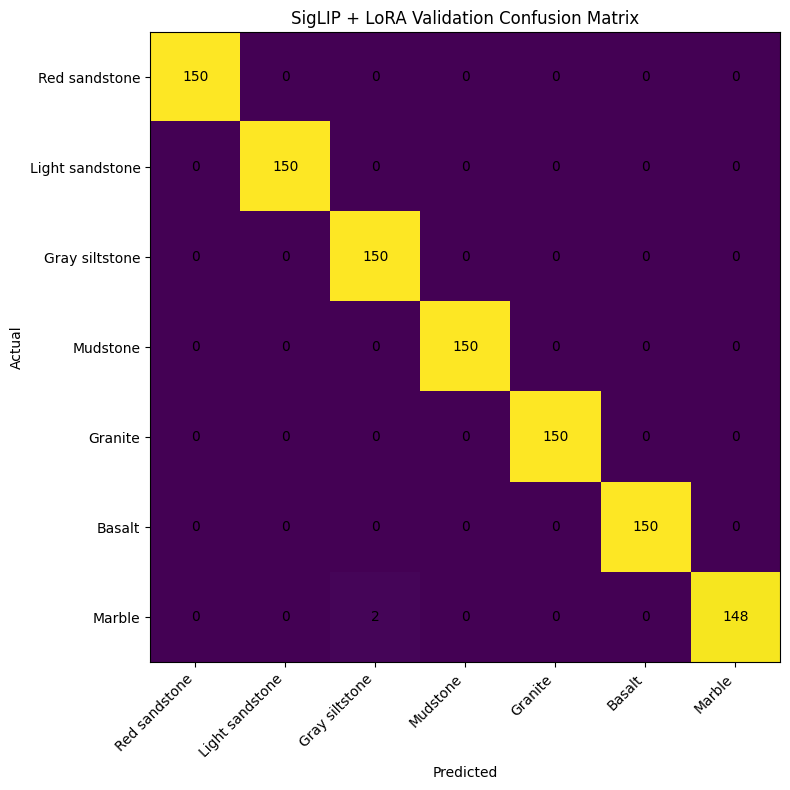

In [34]:
plt.figure(figsize=(9, 8))

plt.imshow(cm)

plt.xticks(
    range(NUM_CLASSES),
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(NUM_CLASSES),
    CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "SigLIP + LoRA Validation Confusion Matrix"
)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [35]:
experiment_config = {
    "model": MODEL_NAME,
    "dataset": "DCID-7",

    "train_images": len(train_df),
    "validation_images": len(val_df),
    "test_images": len(test_df),

    "classes": CLASS_NAMES,

    "lora": {
        "method": "LoRA",
        "rank": LORA_R,
        "alpha": LORA_ALPHA,
        "dropout": LORA_DROPOUT,
        "target_modules": [
            "q_proj",
            "v_proj"
        ]
    },

    "training": {
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY
    },

    "parameters": {
        "total": int(total_parameters),
        "trainable": int(trainable_parameters),
        "trainable_percentage": float(
            trainable_percentage
        )
    },

    "validation": {
        "loss": float(final_val["loss"]),
        "accuracy": float(final_val["accuracy"]),
        "macro_precision": float(
            final_val["macro_precision"]
        ),
        "macro_recall": float(
            final_val["macro_recall"]
        ),
        "macro_f1": float(
            final_val["macro_f1"]
        )
    }
}

with open(
    SAVE_DIR / "experiment_config.json",
    "w"
) as f:
    json.dump(
        experiment_config,
        f,
        indent=4
    )

print("Experiment configuration saved.")


Experiment configuration saved.


In [36]:
from pathlib import Path

print("Saved files:")

for path in sorted(SAVE_DIR.iterdir()):
    size_mb = (
        path.stat().st_size / (1024 ** 2)
        if path.is_file()
        else 0
    )

    print(
        f"{path.name:30s} "
        f"{size_mb:.2f} MB"
    )

Saved files:
best_model.pt                  356.70 MB
experiment_config.json         0.00 MB
per_class_metrics.csv          0.00 MB
training_history.csv           0.00 MB


In [37]:
print("=" * 70)
print("GEOSIGLIP — NOTEBOOK 03 COMPLETE")
print("=" * 70)

print("\nModel:")
print(MODEL_NAME)

print("\nDataset:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nLoRA:")
print("Rank:", LORA_R)
print("Alpha:", LORA_ALPHA)
print("Dropout:", LORA_DROPOUT)
print("Target modules: q_proj, v_proj")

print("\nParameters:")
print(
    "Total:",
    f"{total_parameters:,}"
)
print(
    "Trainable:",
    f"{trainable_parameters:,}"
)
print(
    "Trainable %:",
    f"{trainable_percentage:.4f}%"
)

print("\nValidation:")
print(
    "Accuracy:",
    f"{final_val['accuracy'] * 100:.3f}%"
)
print(
    "Macro F1:",
    f"{final_val['macro_f1'] * 100:.3f}%"
)

print("\nCheckpoint:")
print(
    SAVE_DIR / "best_model.pt"
)

print("\nNotebook 03 finished.")

GEOSIGLIP — NOTEBOOK 03 COMPLETE

Model:
google/siglip-base-patch16-224

Dataset:
Train: 2450
Validation: 1050
Test: 1750

LoRA:
Rank: 16
Alpha: 32
Dropout: 0.05
Target modules: q_proj, v_proj

Parameters:
Total: 93,479,431
Trainable: 595,207
Trainable %: 0.6367%

Validation:
Accuracy: 99.810%
Macro F1: 99.810%

Checkpoint:
/kaggle/working/geosiglip-lora/best_model.pt

Notebook 03 finished.


In [38]:
from IPython.display import FileLink

FileLink(
    "/kaggle/working/geosiglip-lora/best_model.pt"
)

/kaggle/working/geosiglip-lora/best_model.pt